In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class MyState(TypedDict):
    question: str
    result: str

In [3]:
def router(state: MyState) -> str:
    question = state["question"]

    if " 계산" in question:
        return "calculator"

    return "answer"

In [4]:
def calculator_node(state: MyState) -> MyState:
    return {"result": "계산을 완료했습니다."}

In [5]:
def answer_node(state: MyState) -> MyState:
    return {"result": "일반 답변 노드로 이동했습니다."}

In [6]:
graph_builder = StateGraph(MyState)

graph_builder.add_node("calculator", calculator_node)
graph_builder.add_node("answer", answer_node)
graph_builder.add_node("router", router)

In [7]:
graph_builder.add_conditional_edges(START, router)

graph_builder.add_edge("calculator", END)
graph_builder.add_edge("answer", END)

graph = graph_builder.compile()

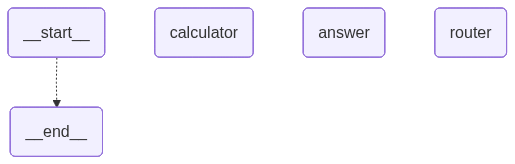

In [8]:
graph

In [9]:
print(graph.invoke({"question": "이 문제 계산해줘"}))

{'question': '이 문제 계산해줘', 'result': '계산을 완료했습니다.'}


In [10]:
print(graph.invoke({"question": "파이썬이 뭐야?"}))

{'question': '파이썬이 뭐야?', 'result': '일반 답변 노드로 이동했습니다.'}


In [11]:
from typing import Annotated, TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

In [12]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [13]:
@tool
def add(a: int, b: int) -> int:
    """두 숫자를 더합니다."""
    print(f"tool : add   a:{a} b:{b}")
    return a + b

In [14]:
@tool
def multiply(a: int, b: int) -> int:
    """두 숫자를 곱합니다."""
    print(f"tool : multiply   a:{a} b:{b}")
    return a * b

In [15]:
tools = [add, multiply]

In [16]:
model = ChatOpenAI(
    model="gpt-5-mini",
)

In [17]:
model_with_tools = model.bind_tools(tools)

In [18]:
def agent_node(state: AgentState):
    response = model_with_tools.invoke(state["messages"])
    print("Agent response : ", response)
    return {"messages": [response]}

In [19]:
def should_continue(state: AgentState):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    else:
        return END

In [20]:
tool_node = ToolNode(tools)

In [21]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges(
    "agent", should_continue, {"tools": "tools", END: END}
)

graph_builder.add_edge("tools", "agent")

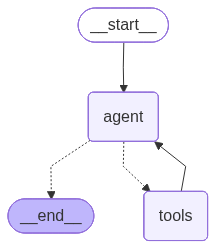

In [22]:
graph = graph_builder.compile()
graph

In [23]:
result = graph.invoke(
    {"messages": [HumanMessage(content="3과 5를 더하고, 그결과에 10을 곱해줘")]}
)

result

Agent response :  content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 538, 'prompt_tokens': 170, 'total_tokens': 708, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 512, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DZSkAbe3Br7c2moPRMkuby5qOOVpz', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019dd1fa-66df-7a61-a33d-0b2f59deda9f-0' tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_SCIbLnil6e0kOBQxH0aySTay', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 170, 'output_tokens': 538, 'total_tokens': 708, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 512}}
tool : add   a:3 b:5
Agen

{'messages': [HumanMessage(content='3과 5를 더하고, 그결과에 10을 곱해줘', additional_kwargs={}, response_metadata={}, id='69a139d8-acca-4bff-973c-29723e56cdc6'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 538, 'prompt_tokens': 170, 'total_tokens': 708, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 512, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DZSkAbe3Br7c2moPRMkuby5qOOVpz', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd1fa-66df-7a61-a33d-0b2f59deda9f-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_SCIbLnil6e0kOBQxH0aySTay', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 170, 'output_tokens': 538, 'total

In [24]:
result["messages"][-1].content

'3 + 5 = 8이고, 8 × 10 = 80입니다. 결과: 80.'

In [25]:
# 병렬화패턴

from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [26]:
model = init_chat_model("gpt-5-nano")

In [27]:
class WriterState(TypedDict):
    topic: str
    sns: str
    youtube: str
    blog: str
    final_report: str

In [28]:
def write_sns(state: WriterState) -> WriterState:
    topic = state["topic"]

    print("sns 홍보안 작성")

    result = model.invoke(f"{topic}에 대한 sns 홍보안의 핵심만 작성해줘")
    return {"sns": result.content}

In [29]:
def write_youtube(state: WriterState) -> WriterState:
    topic = state["topic"]

    print("youtube 홍보안")

    result = model.invoke(f"{topic}에 대한 주제로 youtube홍보안 핵심만 작성해줘")
    return {"youtube": result.content}

In [30]:
def write_blog(state: WriterState) -> WriterState:
    topic = state["topic"]

    print("blog 홍보안")

    result = model.invoke(f"{topic}을 주제로  blog홍보안 핵심만 작성해줘")
    return {"blog": result.content}

In [38]:
def aggregator(state: WriterState):
    print("aggregator 실행")
    final_text = f""" 
    [주제] : {state['topic']} 홍보안

    1.sns 홍보안
    -----------------------------------------------
    {state['sns']}
    -----------------------------------------------

    2.youtube 홍보안
    -----------------------------------------------
    {state['youtube']}
    -----------------------------------------------

    3.blog 홍보안
    -----------------------------------------------
    {state['blog']}

    """

    result = model.invoke(f"{final_text}의 내용을 가지고 홍보 보고서 작성해줘")

    return {"final_report": result.content}

In [39]:
graph_builder = StateGraph(WriterState)

graph_builder.add_node("write_sns", write_sns)
graph_builder.add_node("write_youtube", write_youtube)
graph_builder.add_node("write_blog", write_blog)
graph_builder.add_node("aggregator", aggregator)

In [40]:
graph_builder.add_edge(START, "write_sns")
graph_builder.add_edge(START, "write_youtube")
graph_builder.add_edge(START, "write_blog")

In [41]:
graph_builder.add_edge("write_sns", "aggregator")
graph_builder.add_edge("write_youtube", "aggregator")
graph_builder.add_edge("write_blog", "aggregator")

In [42]:
graph_builder.add_edge("aggregator", END)

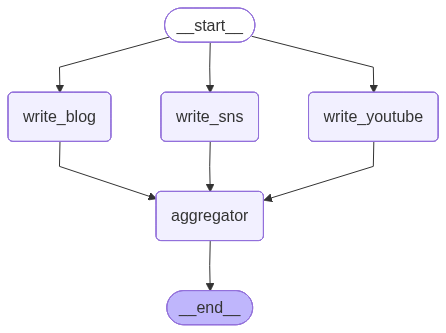

In [43]:
agent = graph_builder.compile()
agent

In [44]:
result = agent.invoke({"topic": "고양 꽃축제"})
result

blog 홍보안
sns 홍보안 작성
youtube 홍보안
aggregator 실행


{'topic': '고양 꽃축제',
 'sns': '다음은 SNS 홍보용 핵심 포맷입니다.\n\n- 핵심 슬로건(3개)\n  - 꽃으로 물든 고양, 봄의 대축제\n  - 사진으로 만나는 봄의 향연, 고양 꽃축제\n  - 가족과 함께하는 꽃길의 축제\n\n- 핵심 메시지 포인트(4개)\n  - 아름다운 꽃길과 다채로운 포토존\n  - 공연·체험 프로그램으로 즐거운 현장 분위기\n  - 가족 친화적 콘텐츠와 안전한 관람Environment\n  - 일정/입장 여부 등은 공식 페이지에서 확인\n\n- 캡션 템플릿(5개)\n  1) 봄이 시작된 고양의 꽃길, 지금 바로 만나보세요. #고양꽃축제\n  2) 대형 플라워 아트와 포토존이 가득! 아이들과 함께 즐겨요. #꽃구경\n  3) 거리 공연과 체험으로 채워지는 하루. 공식 일정 확인 필수! #봄꽃\n  4) 꽃향기 가득한 이곳에서 특별한 봄을 만나요. #사진명소\n  5) 친구 태그하고 같이 가요! #가족나들이\n\n- 추천 해시태그(10개)\n  - #고양꽃축제 #고양시 #꽃축제 #꽃구경 #봄꽃\n  - #꽃길 #꽃스타그램 #가족나들이 #사진명소 #인생샷\n\n- 클릭 유도 CTA(3개)\n  - 팔로우로 일정 업데이트 받기\n  - 공식 페이지에서 상세 일정 확인\n  - 친구 태그해서 함께 초대하기\n\n- 톤앤매너\n  - 밝고 따뜻한 가족 친화적, 사진 중심의 임팩트 있는 문장 사용',
 'youtube': '다음은 고양 꽃축제 YouTube 홍보용 핵심 요약안입니다.\n\n- 핵심 메시지 3가지\n  - 봄의 색채를 한자리에서, 고양 꽃축제에서 만나요.\n  - 가족·연인과 함께하는 체험형 축제(포토존·체험 프로그램·야간 조명).\n  - 누구나 즐길 수 있는 접근성 높은 축제, 오늘 바로 예매.\n\n- 영상 길이/구성(권장: 30초 Teaser)\n  - 0–5초: 훅—씨나리오 예시 멘트와 멋진 꽃 풍경/드론 샷\n  - 5–20초: 축제 하이라이트(포토존, 체험, 공연, 야간 조명) 빠르게 보여주기\

In [45]:
# Evaluator
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

In [49]:
class State(TypedDict):
    question: str
    answer: str
    evaluation: str
    retry_count: int

In [50]:
def generate_answer(state: State):
    answer = f"{state['question']}에 대한 답변입니다."
    return {"answer": answer}

In [51]:
def evaluate_answer(state: State):
    answer = state["answer"]

    if "근거" in answer:
        evaluation = "pass"
    else:
        evaluation = "fail"

    return {"evaluation": evaluation}

In [52]:
def improve_answer(state: State):
    improved = state["answer"] + "  근거를 포함했습니다."
    return {"answer": improved, "retry_count": state["retry_count"] + 1}

In [53]:
def route_after_evaluation(state: State) -> Literal["improve", "end"]:
    if state["evaluation"] == "pass":
        return "end"

    if state["retry_count"] >= 2:
        return "end"

    return "improve"

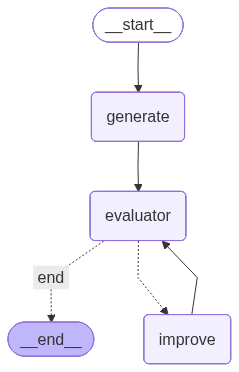

In [54]:
graph = StateGraph(State)
graph.add_node("generate", generate_answer)
graph.add_node("evaluator", evaluate_answer)
graph.add_node("improve", improve_answer)

graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluator")

graph.add_conditional_edges(
    "evaluator", route_after_evaluation, {"improve": "improve", "end": END}
)

graph.add_edge("improve", "evaluator")

agent = graph.compile()

agent